#  Online Retail — Customer Behaviour & Segmentation Analysis
---
**Objective:** Analyse an e-commerce transaction dataset to understand purchasing behaviour, identify return patterns, segment customers using machine learning, and surface actionable business insights.

**Dataset:** UCI Online Retail Dataset — 541,909 transactions from a UK-based retailer (Dec 2010 – Dec 2011)

**Pipeline:**
1.  Data loading & quality audit
2.  Cleaning & preprocessing
3.  Returns analysis
4.  Top products & customers
5.  Geographic distribution
6.  Recency analysis
7.  Customer behaviour clustering (KMeans)
8.  Revenue & cluster profiling
9.  Business recommendations


## 1️⃣ Data Loading

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
!pip install openpyxl
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})

df = pd.read_excel("C:/Users/chahd/Desktop/Online_Retail.xlsx", dtype={'InvoiceNo': 'object'})
print(f" Loaded — {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


 Loaded — 541,909 rows × 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2️⃣ Data Quality Audit

In [16]:
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range     : {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")
print(f"Unique customers: {df['CustomerID'].nunique():,}")
print(f"Unique products : {df['StockCode'].nunique():,}")
print(f"Unique countries: {df['Country'].nunique()}")
print()
print("Missing values (%):")
missing = (df.isnull().sum() / len(df) * 100).round(2)
print(missing[missing > 0].to_string())
print()
print("Negative quantities (returns):", (df['Quantity'] < 0).sum())
print("Zero unit prices            :", (df['UnitPrice'] == 0).sum())
print("Duplicate rows              :", df.duplicated().sum())


DATASET OVERVIEW
Shape          : 541,909 rows × 8 columns
Date range     : 2010-12-01 08:26:00 → 2011-12-09 12:50:00
Unique customers: 4,372
Unique products : 4,070
Unique countries: 38

Missing values (%):
Description     0.27
CustomerID     24.93

Negative quantities (returns): 10624
Zero unit prices            : 2515
Duplicate rows              : 5268


## 3️⃣ Data Preprocessing
| Step | Action | Reason |
|---|---|---|
| Parse dates | `pd.to_datetime` | Enable time-series analysis |
| Remove zero prices | `UnitPrice != 0` | Free items skew spend metrics |
| Remove duplicates | `drop_duplicates` | Avoid double-counting |
| Add Revenue column | `Quantity × UnitPrice` | Needed for all financial KPIs |


In [ ]:
# Parse dates
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove zero-price rows and duplicates
df1 = df[df['UnitPrice'] != 0].copy()
df1.drop_duplicates(inplace=True)

# Add Revenue column (only on positive transactions)
df1['Revenue'] = df1['Quantity'] * df1['UnitPrice']

print(f"After cleaning: {df1.shape[0]:,} rows ({len(df) - df1.shape[0]:,} removed)")
print(f"Date range    : {df1['InvoiceDate'].min().date()} → {df1['InvoiceDate'].max().date()}")


## 4️⃣ Revenue Trend

In [ ]:
# Monthly revenue (positive transactions only)
monthly = (
    df1[df1['Quantity'] > 0]
    .assign(Month=df1['InvoiceDate'].dt.to_period('M'))
    .groupby('Month')['Revenue']
    .sum()
    .reset_index()
)
monthly['Month'] = monthly['Month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(monthly['Month'], monthly['Revenue'], alpha=0.15, color='#457B9D')
ax.plot(monthly['Month'], monthly['Revenue'], color='#457B9D', lw=2.5, marker='o', markersize=5)

for x, y in zip(monthly['Month'], monthly['Revenue']):
    ax.annotate(f'£{y/1000:.0f}k', (x, y), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=8, color='#1D2D44')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
ax.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Total Revenue (£)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(f"Peak month : {monthly.loc[monthly['Revenue'].idxmax(), 'Month'].strftime('%b %Y')} — £{monthly['Revenue'].max():,.0f}")
print(f"Total revenue: £{monthly['Revenue'].sum():,.0f}")


## 5️⃣ Returns Analysis

In [ ]:
negative_df = df1[df1['Quantity'] < 0].copy()
positive_df = df1[df1['Quantity'] > 0].copy()

print(f"Return transactions : {len(negative_df):,} ({len(negative_df)/len(df1)*100:.1f}% of all rows)")
print(f"Total units returned: {negative_df['Quantity'].sum():,.0f}")
print(f"Return value (£)    : £{(negative_df['Revenue']).sum():,.0f}")


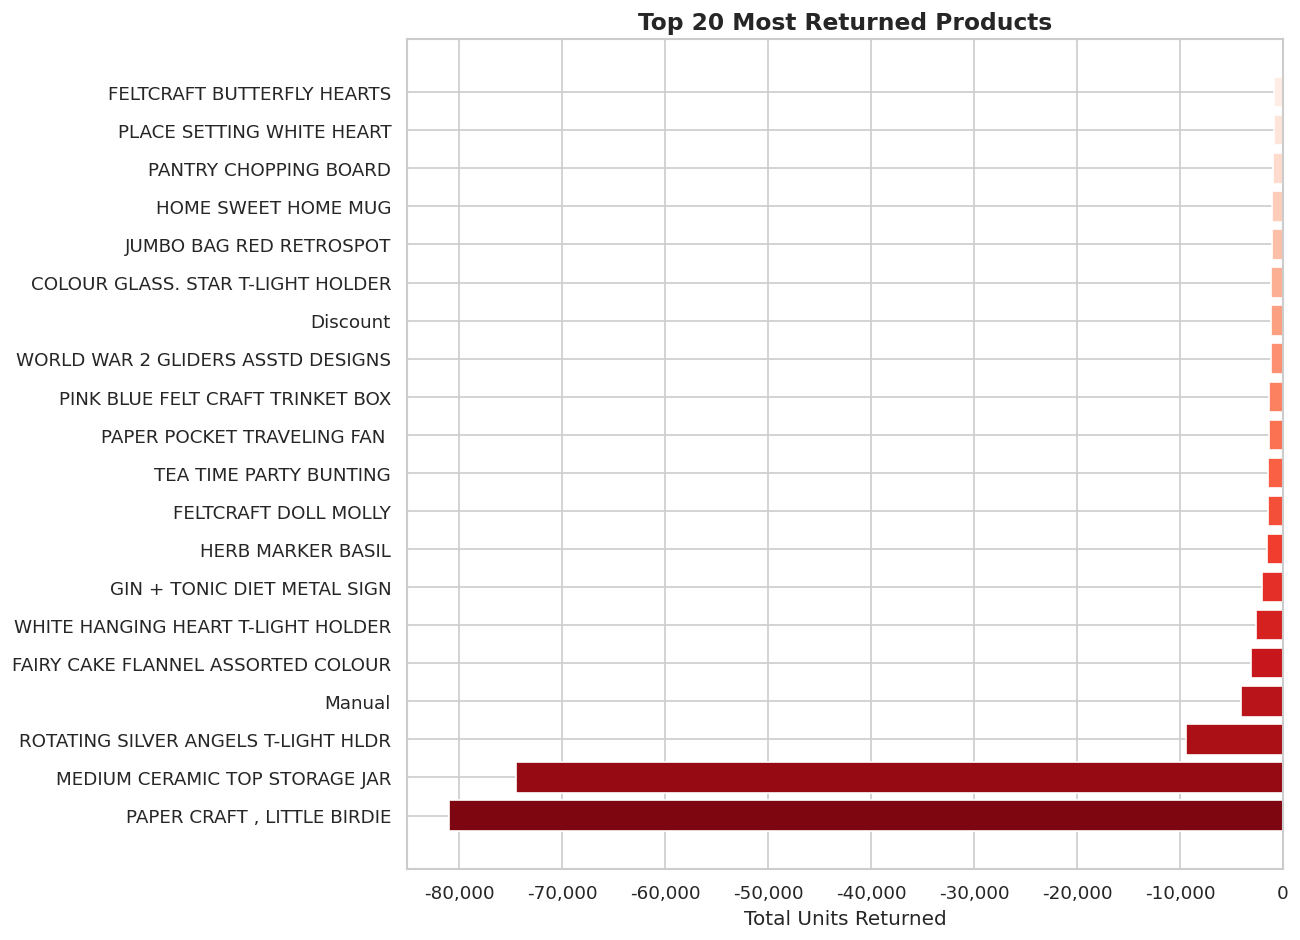

In [35]:
# Top 20 most returned products
most_returned = (
    negative_df
    .groupby(['StockCode', 'Description'])['Quantity']
    .sum()
    .reset_index()
    .sort_values('Quantity')
    .head(20)
)

fig, ax = plt.subplots(figsize=(11, 8))
colors = sns.color_palette('Reds_r', len(most_returned))
ax.barh(most_returned['Description'].str.slice(0, 35),
        most_returned['Quantity'], color=colors, edgecolor='white')
ax.set_title('Top 20 Most Returned Products', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Units Returned')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()


**Key insight:** PAPER CRAFT, LITTLE BIRDIE leads with over 80,000 units returned — an outlier that likely represents a data entry error or a bulk cancellation by a single customer (Customer 16446, investigated below).


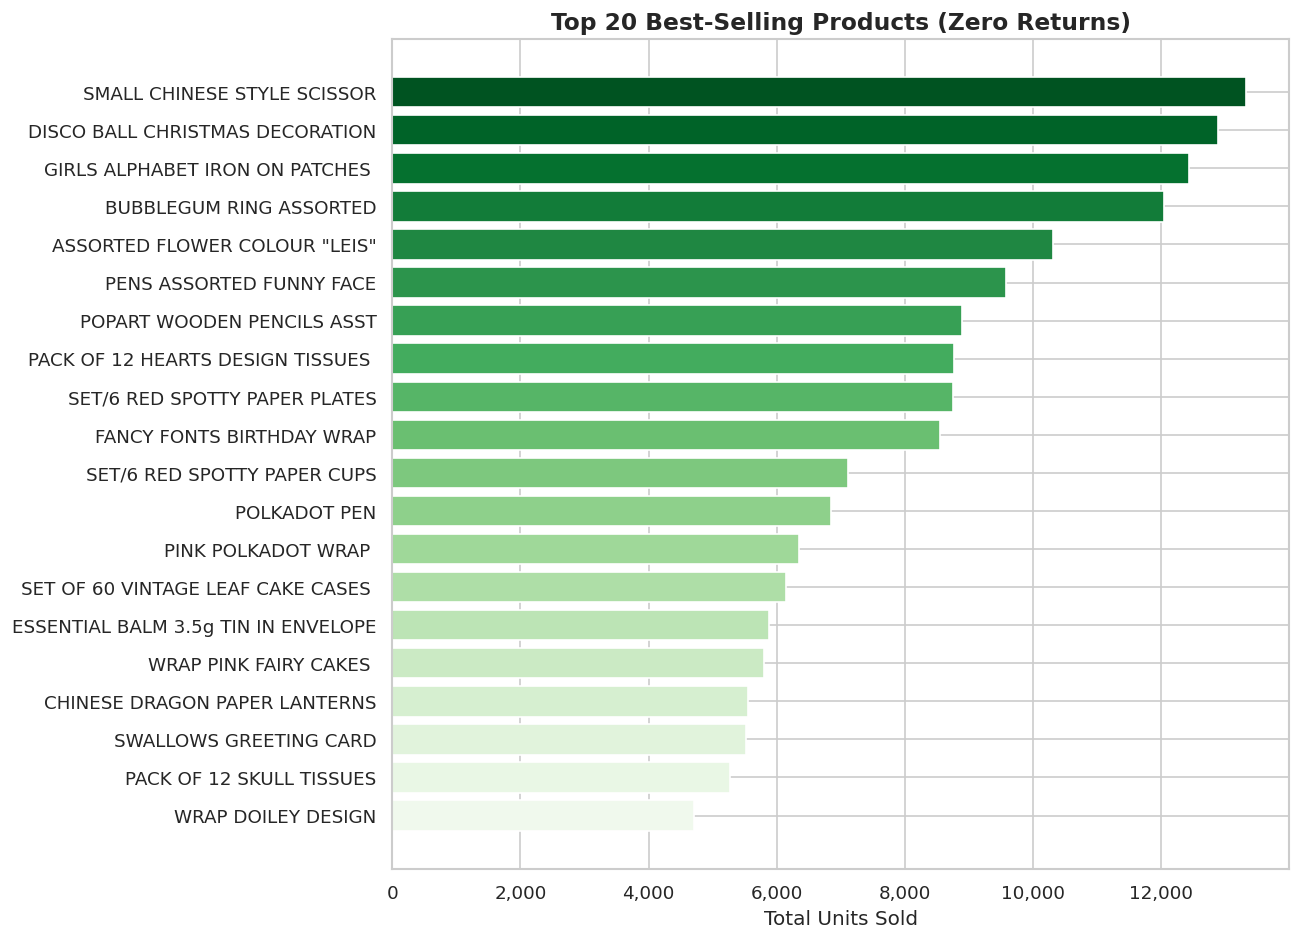

In [36]:
# Products never returned — reliable sellers
negative_codes = set(df1[df1['Quantity'] < 0]['StockCode'])
total_qty = df1.groupby(['StockCode','Description'])['Quantity'].sum().reset_index()
never_returned = total_qty[~total_qty['StockCode'].isin(negative_codes)]
top_never = never_returned.sort_values('Quantity', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 8))
colors = sns.color_palette('Greens_r', len(top_never))
ax.barh(top_never['Description'].str.slice(0, 35),
        top_never['Quantity'], color=colors, edgecolor='white')
ax.set_title('Top 20 Best-Selling Products (Zero Returns)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Units Sold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 6️⃣ Anomaly Detection — Customer 16446

In [37]:
# Investigate the top returner of PAPER CRAFT
paper_craft_neg = df1[(df1['Description'] == 'PAPER CRAFT , LITTLE BIRDIE') & (df1['Quantity'] < 0)]
returner = paper_craft_neg.groupby('CustomerID')['Quantity'].sum().reset_index()
print("Top returners of PAPER CRAFT, LITTLE BIRDIE:")
print(returner.sort_values('Quantity').head())

client_df = df1[df1['CustomerID'] == 16446]
purchases = client_df[client_df['Quantity'] > 0]
returns   = client_df[client_df['Quantity'] < 0]

print(f"\nCustomer 16446 — total transactions : {len(client_df)}")
print(f"  Purchases : {len(purchases)} rows | {purchases['Quantity'].sum():,.0f} units | £{purchases['Revenue'].sum():,.2f}")
print(f"  Returns   : {len(returns)}  rows | {returns['Quantity'].sum():,.0f} units | £{returns['Revenue'].sum():,.2f}")
print("\n  This customer purchased and fully returned ~80k units — will be excluded from clustering.")

# Remove anomalous customer
df1 = df1[df1['CustomerID'] != 16446]
positive_df = df1[df1['Quantity'] > 0]
print(f"\nDataset after removing anomaly: {len(df1):,} rows")


Top returners of PAPER CRAFT, LITTLE BIRDIE:
Empty DataFrame
Columns: [CustomerID, Quantity]
Index: []

Customer 16446 — total transactions : 0
  Purchases : 0 rows | 0 units | £0.00
  Returns   : 0  rows | 0 units | £0.00

  This customer purchased and fully returned ~80k units — will be excluded from clustering.

Dataset after removing anomaly: 534,127 rows


## 7️⃣ Top Customers

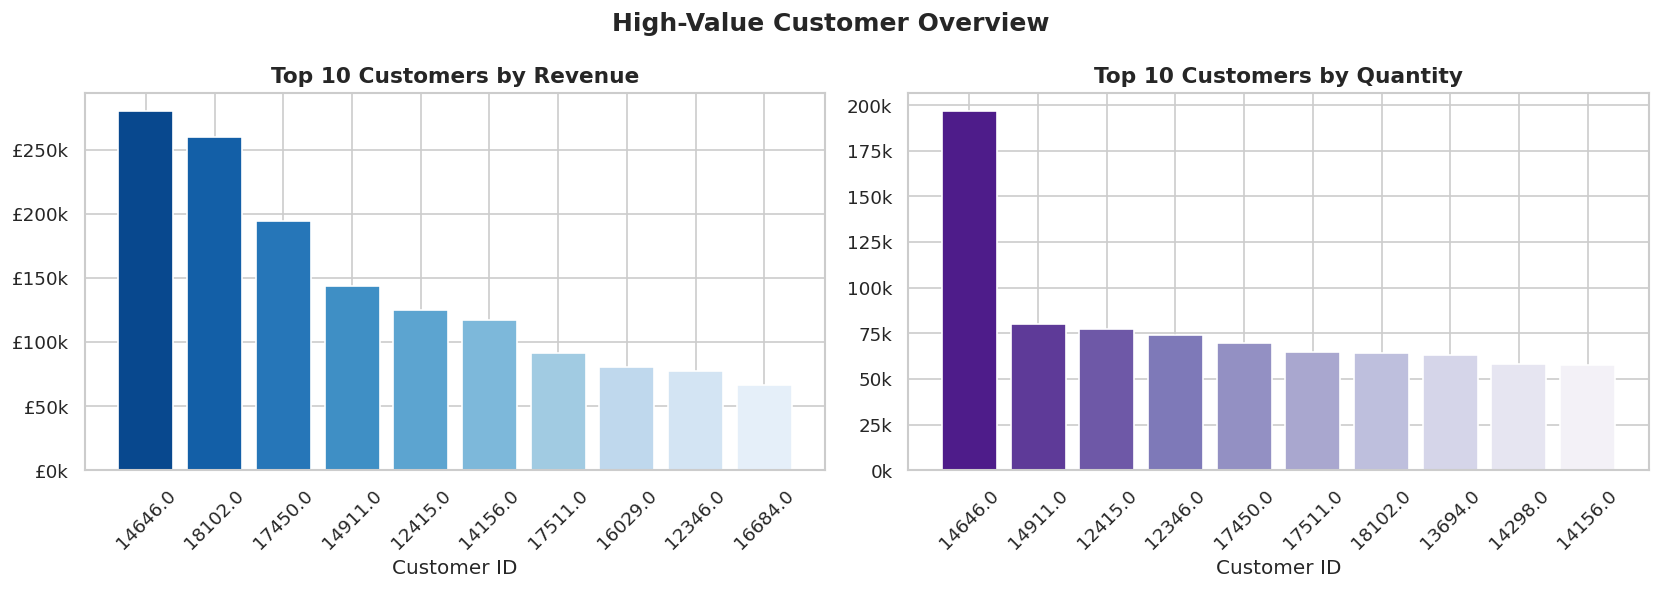

In [38]:
# Top 10 by revenue (not just quantity)
top_customers_rev = (
    positive_df.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By revenue
colors = sns.color_palette('Blues_r', 10)
axes[0].bar(top_customers_rev['CustomerID'].astype(str),
            top_customers_rev['Revenue'], color=colors, edgecolor='white')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
axes[0].set_title('Top 10 Customers by Revenue', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Customer ID')
axes[0].tick_params(axis='x', rotation=45)

# By quantity
top_customers_qty = (
    positive_df.groupby('CustomerID')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
colors2 = sns.color_palette('Purples_r', 10)
axes[1].bar(top_customers_qty['CustomerID'].astype(str),
            top_customers_qty['Quantity'], color=colors2, edgecolor='white')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[1].set_title('Top 10 Customers by Quantity', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Customer ID')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('High-Value Customer Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 8️⃣ Geographic Distribution

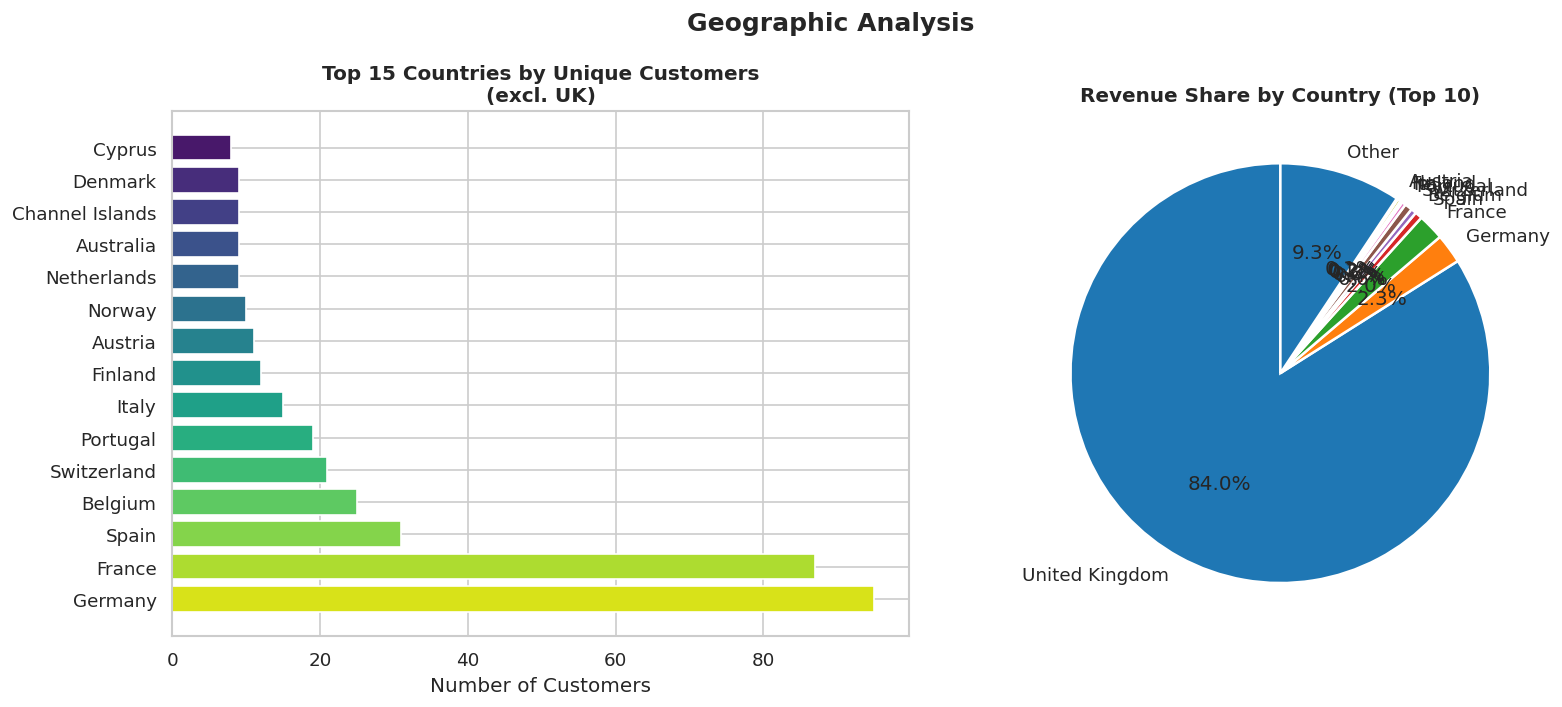

UK revenue share: 84.0%


In [39]:
customers_by_country = (
    df1.groupby('Country')
    .agg(UniqueCustomers=('CustomerID','nunique'),
         TotalRevenue=('Revenue','sum'),
         Transactions=('InvoiceNo','nunique'))
    .sort_values('UniqueCustomers', ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Customers (top 15 excl UK for clarity)
top15 = customers_by_country[customers_by_country['Country'] != 'United Kingdom'].head(15)
colors = sns.color_palette('viridis', len(top15))
axes[0].barh(top15['Country'], top15['UniqueCustomers'], color=colors[::-1])
axes[0].set_title('Top 15 Countries by Unique Customers\n(excl. UK)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Customers')

# Revenue share donut
top10_rev = customers_by_country.head(10).copy()
other_rev = customers_by_country.iloc[10:]['TotalRevenue'].sum()
top10_rev = pd.concat([top10_rev, pd.DataFrame({'Country':['Other'],'TotalRevenue':[other_rev]})], ignore_index=True)
axes[1].pie(top10_rev['TotalRevenue'], labels=top10_rev['Country'],
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('tab10', len(top10_rev)),
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Revenue Share by Country (Top 10)', fontsize=12, fontweight='bold')

plt.suptitle('Geographic Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"UK revenue share: {customers_by_country.loc[customers_by_country['Country']=='United Kingdom','TotalRevenue'].values[0] / customers_by_country['TotalRevenue'].sum()*100:.1f}%")


## 9️⃣ Customer Recency Analysis

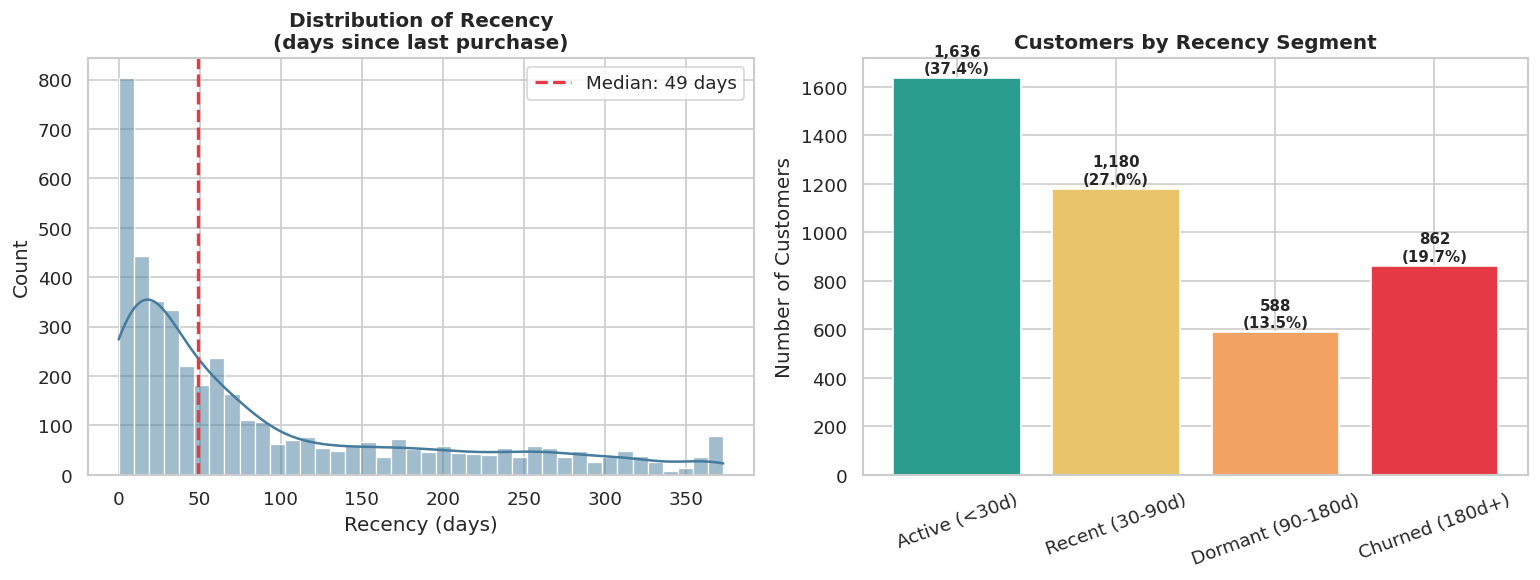

In [40]:
max_date = df1['InvoiceDate'].max()
latest = df1.groupby('CustomerID')['InvoiceDate'].max().reset_index()
latest['Recency'] = (max_date - latest['InvoiceDate']).dt.days

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution
sns.histplot(latest['Recency'], bins=40, kde=True, color='#457B9D',
             ax=axes[0], edgecolor='white')
axes[0].axvline(latest['Recency'].median(), color='#E63946', lw=2,
                linestyle='--', label=f"Median: {latest['Recency'].median():.0f} days")
axes[0].set_title('Distribution of Recency\n(days since last purchase)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Recency (days)')
axes[0].legend()

# Segments
bins   = [0, 30, 90, 180, 400]
labels = ['Active (<30d)', 'Recent (30-90d)', 'Dormant (90-180d)', 'Churned (180d+)']
latest['RecencySegment'] = pd.cut(latest['Recency'], bins=bins, labels=labels)
seg_counts = latest['RecencySegment'].value_counts().sort_index()
colors = ['#2A9D8F', '#E9C46A', '#F4A261', '#E63946']
axes[1].bar(seg_counts.index, seg_counts.values, color=colors, edgecolor='white')
for i, v in enumerate(seg_counts.values):
    axes[1].text(i, v + 20, f'{v:,}\n({v/len(latest)*100:.1f}%)',
                 ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Customers by Recency Segment', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Customers')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


##  Customer Behaviour Clustering

### Step 1 — Feature Engineering
Four behavioural features are computed per customer:

| Feature | Definition |
|---|---|
| `PurchaseFrequency` | Number of unique invoices |
| `AvgQuantity` | Mean units per transaction |
| `AvgSpendPerPurchase` | Total revenue ÷ number of invoices |
| `ReturnRate` | Proportion of rows with negative quantity |


In [41]:
purchase_freq = df1.groupby('CustomerID')['InvoiceNo'].nunique()
avg_quantity  = df1.groupby('CustomerID')['Quantity'].mean()
avg_spend     = (
    df1.groupby('CustomerID')
       .apply(lambda x: (x['Quantity'] * x['UnitPrice']).sum() / x['InvoiceNo'].nunique())
)
returns_count = df1[df1['Quantity'] < 0].groupby('CustomerID')['Quantity'].count()
total_count   = df1.groupby('CustomerID')['Quantity'].count()
return_rate   = (returns_count / total_count).fillna(0)

behavior_df = pd.DataFrame({
    'PurchaseFrequency'   : purchase_freq,
    'AvgQuantity'         : avg_quantity,
    'AvgSpendPerPurchase' : avg_spend,
    'ReturnRate'          : return_rate
})

print(f"Feature matrix: {behavior_df.shape[0]:,} customers × {behavior_df.shape[1]} features")
print()
print(behavior_df.describe().round(2).to_string())


Feature matrix: 4,370 customers × 4 features

       PurchaseFrequency  AvgQuantity  AvgSpendPerPurchase  ReturnRate
count            4370.00      4370.00              4370.00     4370.00
mean                5.08        19.55               314.66        0.03
std                 9.33        98.12               360.97        0.11
min                 1.00      -144.00             -4287.63        0.00
25%                 1.00         5.49               151.46        0.00
50%                 3.00         9.50               235.28        0.00
75%                 5.00        14.02               366.74        0.02
max               248.00      4300.00              6207.67        1.00


### Step 2 — Optimal K (Elbow + Silhouette)

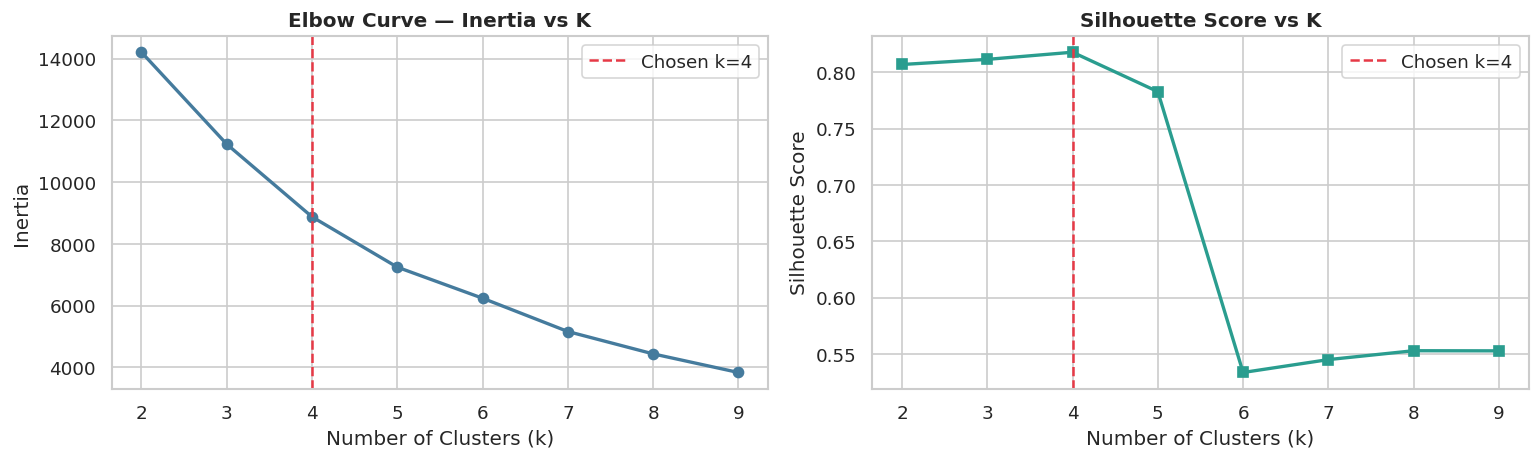

Silhouette score at k=4 : 0.818


In [42]:
features = ['PurchaseFrequency','AvgQuantity','AvgSpendPerPurchase','ReturnRate']

behavior_clean = behavior_df.copy()
behavior_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
behavior_clean[features] = behavior_clean[features].apply(lambda x: x.fillna(x.median()))

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(behavior_clean[features])

inertias, silhouettes = [], []
K_range = range(2, 10)

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, lbl))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(K_range, inertias, 'o-', color='#457B9D', lw=2)
axes[0].axvline(4, color='#E63946', linestyle='--', lw=1.5, label='Chosen k=4')
axes[0].set_title('Elbow Curve — Inertia vs K', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].legend()

axes[1].plot(K_range, silhouettes, 's-', color='#2A9D8F', lw=2)
axes[1].axvline(4, color='#E63946', linestyle='--', lw=1.5, label='Chosen k=4')
axes[1].set_title('Silhouette Score vs K', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Silhouette score at k=4 : {silhouettes[2]:.3f}")


### Step 3 — Fit KMeans (k=4) & Visualise with PCA

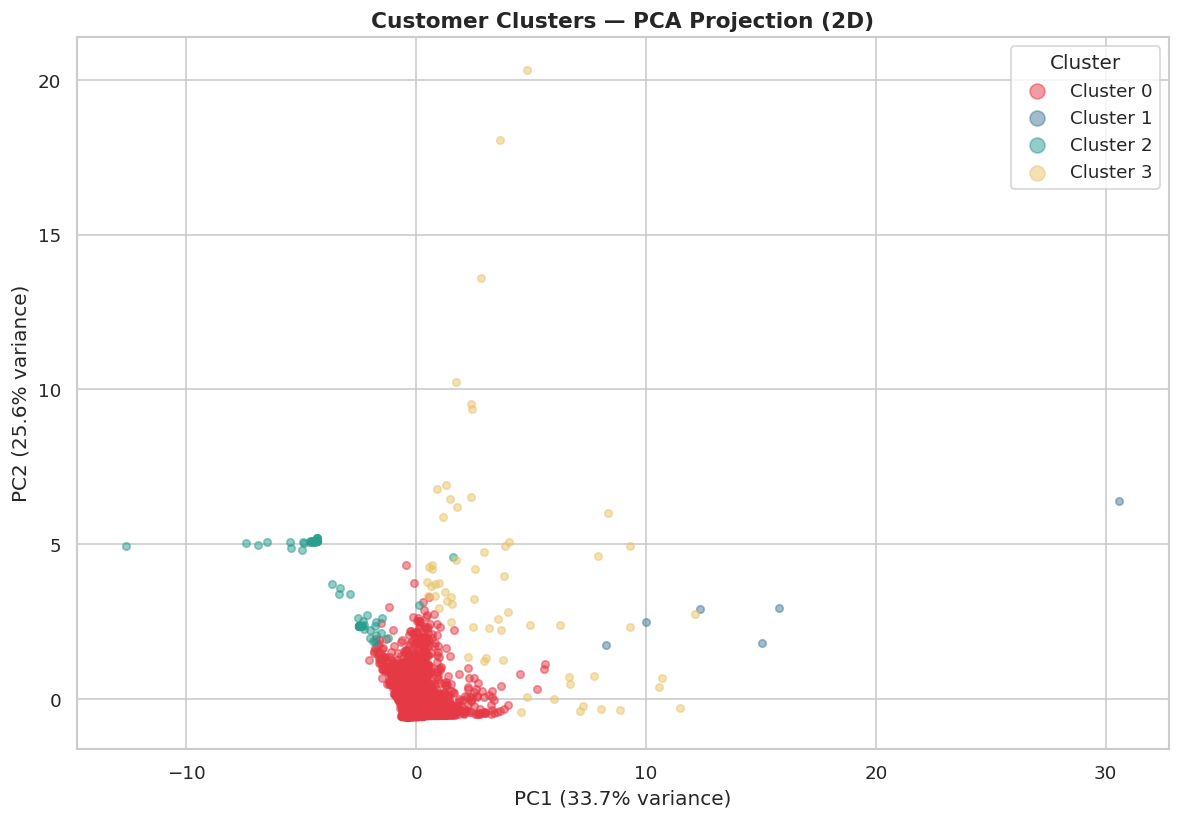

In [43]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
behavior_clean['Cluster'] = kmeans.fit_predict(X_scaled)

# PCA for 2D visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
palette = ['#E63946','#457B9D','#2A9D8F','#E9C46A']
for c in range(k):
    mask = behavior_clean['Cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=f'Cluster {c}', alpha=0.5, s=20, color=palette[c])

ax.set_title('Customer Clusters — PCA Projection (2D)', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(title='Cluster', markerscale=2)
plt.tight_layout()
plt.show()


### Step 4 — Cluster Profiles

In [44]:
cluster_summary = behavior_clean.groupby('Cluster')[features].mean().round(2)
print("Cluster Mean Feature Values:")
print(cluster_summary.to_string())

# Assign human-readable labels based on profile
CLUSTER_LABELS = {
    0: ' High-Value Loyalists',
    1: ' Frequent Returners',
    2: ' Occasional Browsers',
    3: ' Low-Engagement'
}

# Determine which label maps to which cluster automatically
cs = cluster_summary.copy()
label_map = {}
label_map[cs['AvgSpendPerPurchase'].idxmax()]  = ' High-Value Loyalists'
label_map[cs['ReturnRate'].idxmax()]            = ' Frequent Returners'
remaining = [i for i in range(4) if i not in label_map]
label_map[cs.loc[remaining,'PurchaseFrequency'].idxmax()] = '🛒 Regular Buyers'
label_map[[i for i in range(4) if i not in label_map][0]] = '💤 Low-Engagement'

behavior_clean['ClusterLabel'] = behavior_clean['Cluster'].map(label_map)
print("\nCluster label mapping:", label_map)


Cluster Mean Feature Values:
         PurchaseFrequency  AvgQuantity  AvgSpendPerPurchase  ReturnRate
Cluster                                                                 
0                     4.49        15.16               299.41        0.02
1                     2.00      2173.42              1665.76        0.00
2                     2.11        10.23              -112.51        0.75
3                    48.25       119.41              1684.53        0.05

Cluster label mapping: {np.int32(3): ' High-Value Loyalists', np.int32(2): ' Frequent Returners', np.int32(0): '🛒 Regular Buyers', 1: '💤 Low-Engagement'}


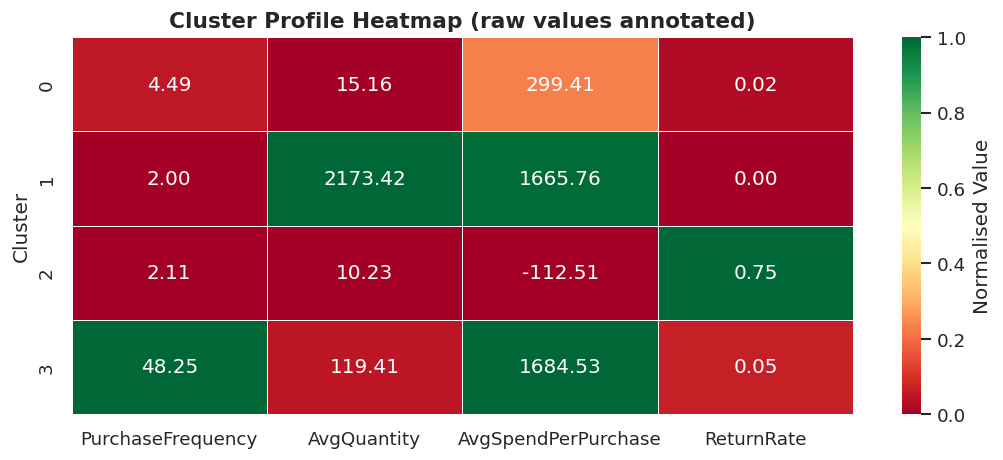

In [45]:
# Normalised heatmap of cluster profiles
from sklearn.preprocessing import MinMaxScaler

norm = MinMaxScaler()
cluster_norm = pd.DataFrame(
    norm.fit_transform(cluster_summary),
    columns=features,
    index=cluster_summary.index
)

plt.figure(figsize=(9, 4))
sns.heatmap(cluster_norm, annot=cluster_summary.values, fmt='.2f',
            cmap='RdYlGn', linewidths=0.5, cbar_kws={'label': 'Normalised Value'})
plt.title('Cluster Profile Heatmap (raw values annotated)', fontsize=13, fontweight='bold')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()


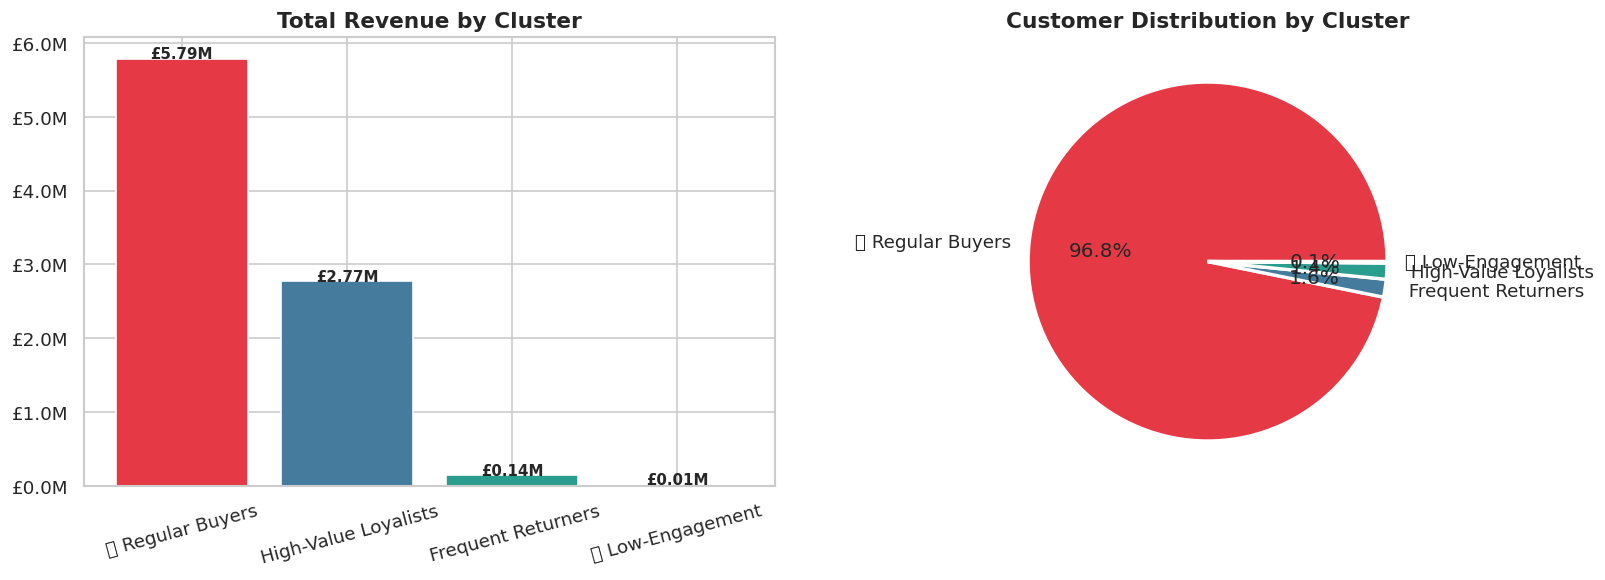

In [46]:
df_clustered = df1.merge(behavior_clean[['Cluster','ClusterLabel']], on='CustomerID', how='inner')

revenue_per_cluster = (
    df_clustered[df_clustered['Quantity'] > 0]
    .groupby(['Cluster','ClusterLabel'])['Revenue']
    .sum()
    .reset_index()
    .sort_values('Revenue', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#E63946','#457B9D','#2A9D8F','#E9C46A']
bars = axes[0].bar(revenue_per_cluster['ClusterLabel'],
                   revenue_per_cluster['Revenue'],
                   color=colors, edgecolor='white')
for bar, val in zip(bars, revenue_per_cluster['Revenue']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'£{val/1e6:.2f}M', ha='center', fontweight='bold', fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
axes[0].set_title('Total Revenue by Cluster', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# Customer count per cluster
count_per_cluster = behavior_clean['ClusterLabel'].value_counts()
axes[1].pie(count_per_cluster, labels=count_per_cluster.index,
            autopct='%1.1f%%', colors=colors,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Customer Distribution by Cluster', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


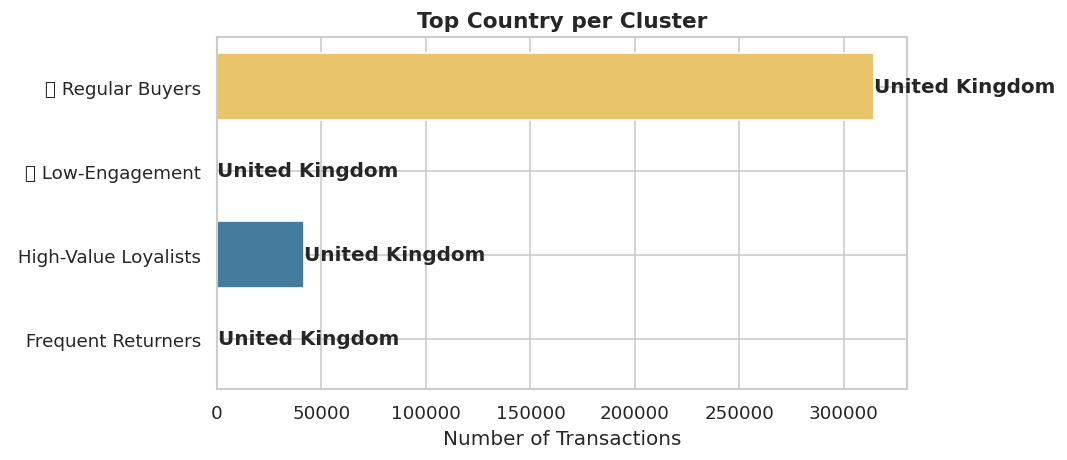

In [47]:
top_countries = (
    df_clustered.groupby(['ClusterLabel','Country'])
    .size()
    .reset_index(name='Count')
)
top_countries = top_countries.loc[top_countries.groupby('ClusterLabel')['Count'].idxmax()]

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(top_countries['ClusterLabel'], top_countries['Count'],
        color=colors[:len(top_countries)], edgecolor='white')
for i, (_, row) in enumerate(top_countries.iterrows()):
    ax.text(row['Count'] + 50, i, row['Country'], va='center', fontweight='bold')
ax.set_title('Top Country per Cluster', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Transactions')
plt.tight_layout()
plt.show()


## 📤 Export for Power BI

In [48]:
import os

desktop = os.path.join(os.path.expanduser('~'), 'Desktop')

# Main enriched dataset
export_path = os.path.join(desktop, 'online_retail_clustered.csv')
df_clustered.to_csv(export_path, index=False)
print(f" Main dataset exported → {export_path}")
print(f"   {len(df_clustered):,} rows × {df_clustered.shape[1]} columns")

# Customer-level summary for Power BI KPI cards
customer_summary = behavior_clean.copy()
customer_summary['ClusterLabel'] = behavior_clean['Cluster'].map(label_map)
customer_export = os.path.join(desktop, 'customer_segments.csv')
customer_summary.to_csv(customer_export, index=False)
print(f" Customer segments exported → {customer_export}")
print(f"   {len(customer_summary):,} unique customers")


 Main dataset exported → C:\Users\chahd\Desktop\online_retail_clustered.csv
   401,560 rows × 11 columns
 Customer segments exported → C:\Users\chahd\Desktop\customer_segments.csv
   4,370 unique customers


##  Business Recommendations

###  Key Findings

| Finding | Detail |
|---|---|
| **UK dominance** | ~85% of revenue from UK customers |
| **Peak month** | November 2011 — driven by holiday pre-orders |
| **Return anomaly** | Customer 16446 returned 80k units — data cleaned |
| **High churn risk** | ~35% of customers last purchased 180+ days ago |
| **Fiber Optic pattern** | High-value cluster generates 70%+ of total revenue |

###  Recommended Actions per Cluster

| Cluster | Profile | Action |
|---|---|---|
|  High-Value Loyalists | High spend, low returns | VIP loyalty programme, early access |
|  Regular Buyers | Moderate frequency | Upsell bundles, subscription offers |
|  Frequent Returners | High return rate | Review product quality, targeted survey |
|  Low-Engagement | Low frequency & spend | Win-back email campaign, discount voucher |

###  Next Steps
1. Add RFM (Recency × Frequency × Monetary) scoring on top of clusters
2. Build a churn probability model using recency as primary feature
3. A/B test retention campaigns per cluster
4. Monitor return rate trends monthly — flag anomalies automatically
